# HW1 : Regression
Instructions: https://www.cs.tufts.edu/cs/135/2026s/hw1.html

In [3]:
import os
import numpy as np
import pandas as pd
 
import sklearn.preprocessing
import sklearn.pipeline
import sklearn.linear_model

In [4]:
from matplotlib import pyplot as plt

import seaborn as sns
#This sets the default style for all figures. 
sns.set('notebook', font_scale=1.25, style='whitegrid')

### Loading the data

Make sure `dataset_auto.csv` is in the same directory as this notebook

In [5]:
# Let's look at the first few lines of the data file.

with open('dataset_auto.csv', 'r') as f:
    for line in f.readlines()[:5]:
        print(line.strip())

mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
18,8,307,130,3504,12,70,1,chevrolet chevelle malibu
15,8,350,165,3693,11.5,70,1,buick skylark 320
18,8,318,150,3436,11,70,1,plymouth satellite
16,8,304,150,3433,12,70,1,amc rebel sst


In [6]:
# A richer examination of the dataset is included in the day01 Pandas/Matplotlib lab.
# We want to drop rows with missing horsepower values (represented by '?') and then
# grab the columns of interest: mpg (0), displacement (2) and horsepower (3)

auto_arr = np.loadtxt('dataset_auto.csv', delimiter=',', skiprows=1, dtype=str)
auto_arr = auto_arr[auto_arr[:,3] != '?']
auto_arr = np.asarray(auto_arr[:,[0,2,3]], dtype=np.float64)

### Methods for loading dataset

In [7]:
# the last column of our 3-column data set is horsepower
x_N_horsepower = auto_arr[:,2]

# your linear model expects an input of size (N,1)
x_N1_horsepower = x_N_horsepower[:,np.newaxis] 

# the firs two columns are mpg and displacement
y_N_mpg = auto_arr[:,0]
y_N_displacement = auto_arr[:,1]

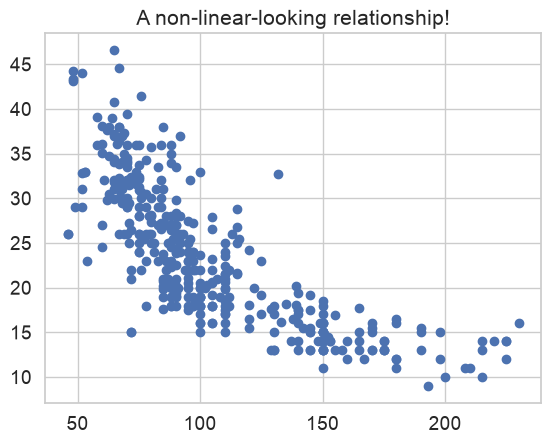

In [8]:
plt.scatter(x_N_horsepower, y_N_mpg)
plt.title("A non-linear-looking relationship!")
plt.show()

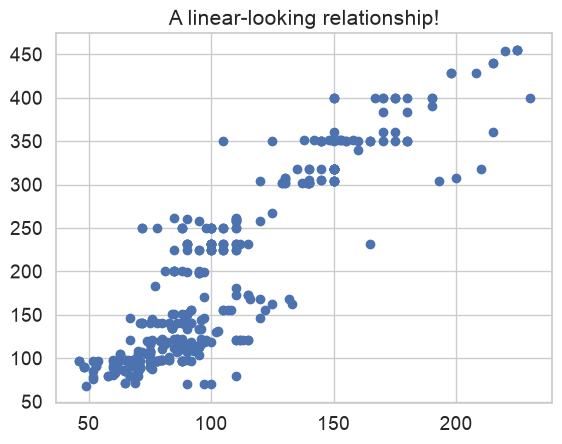

In [9]:
plt.scatter(x_N_horsepower, y_N_displacement)
plt.title("A linear-looking relationship!")
plt.show()

# Fitting a parabola

The provided code constructs a quadratic regression model and fits it to the hosepower-mpg problem. We can visualize the fit parabola by evaluating it on a dense grid of points; the commented-out line of code which produces the parabola will raise errors until you've finished your implementation.

In [10]:
from LeastSquaresQuadraticRegression import LeastSquaresQuadraticRegressor

quad_regr = LeastSquaresQuadraticRegressor()
quad_regr.fit(x_N_horsepower, y_N_mpg)

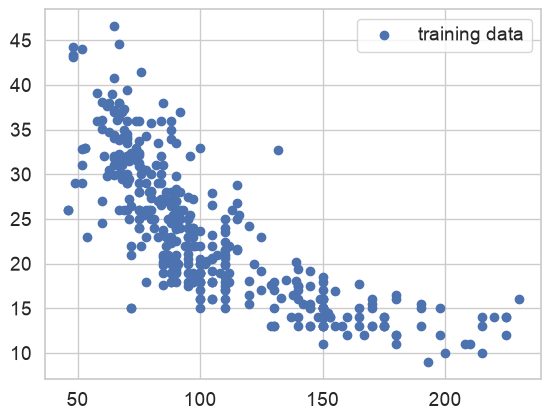

In [11]:
grid = np.linspace(50,250, 100)
y_hats = quad_regr.predict(grid)

plt.scatter(x_N_horsepower, y_N_mpg, label='training data')
# plt.plot(grid, y_hats, label='fit parabola', color='red')
plt.legend()
plt.show()

There's plenty more to do, but you'll have to write the code yourself! Remember you need to compute the rMSE of a line and a parabola on the 2 regression problems mentioned in the assignment instructions.

Report Task 1(a) Provide the 4 rMSE values you computed above in a typeset 2 by 2 table. There should be one column for each model (column 1 is linear, column 2 is quadratic) and one row for each regression task. Please provide values up to 2 decimal places.

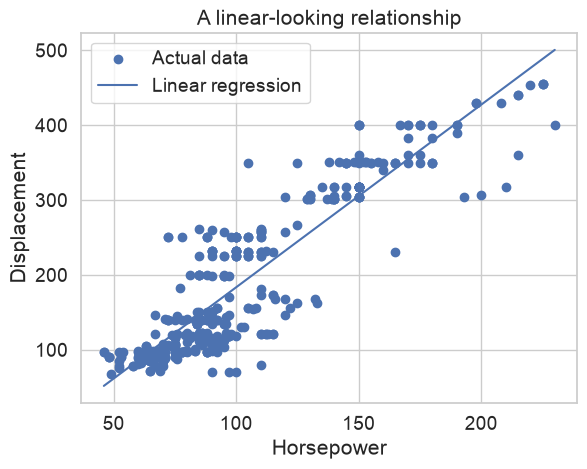

RMSE: 46.142263300853244


In [49]:
from LeastSquaresLinearRegression import LeastSquaresLinearRegressor
from performance_metrics import calc_root_mean_squared_error

# Change (N,) -> (N, 1)
x_N_horsepower = x_N_horsepower.reshape(-1, 1)

# Fit model
lin_regr = LeastSquaresLinearRegressor()
lin_regr.fit(x_N_horsepower, y_N_displacement)

# Predictions for original data
yhat_N = lin_regr.predict(x_N_horsepower)

# Create x values for drawing the regression line
x = np.linspace(
    x_N_horsepower.min(),
    x_N_horsepower.max(),
    260
)

# Change (260,) -> (260, 1)
x_line_2d = x.reshape(-1, 1)

# Predict y values for the line
y_line = lin_regr.predict(x_line_2d)

# ---- SAME GRAPH ----
plt.scatter(
    x_N_horsepower.ravel(),
    y_N_displacement,
    label="Actual data"
)

plt.plot(
    x,
    y_line,
    label="Linear regression"
)

plt.title("A linear-looking relationship")
plt.xlabel("Horsepower")
plt.ylabel("Displacement")
plt.legend()

plt.show()

# RMSE
rmse = calc_root_mean_squared_error(
    y_N_displacement,
    yhat_N
)

print("RMSE:", rmse)

Fit a quadratic model to the same data, and compute the rMSE.


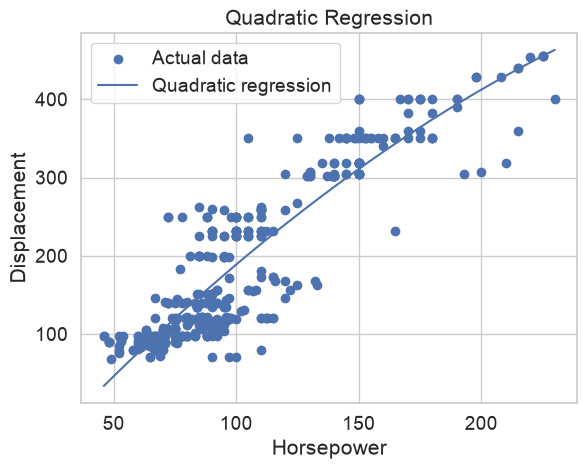

RMSE: 45.530056216651005


In [59]:
from LeastSquaresQuadraticRegression import LeastSquaresQuadraticRegressor
from performance_metrics import calc_root_mean_squared_error

# Keep x as 1D (N,)
# x_N_horsepower should be shape (N,)

# Fit model
quad_regr = LeastSquaresQuadraticRegressor()
quad_regr.fit(x_N_horsepower, y_N_displacement)

# Predictions
yhat_N = quad_regr.predict(x_N_horsepower)
yhat_N = np.asarray(yhat_N).ravel()

# x values for smooth curve
x = np.linspace(
    x_N_horsepower.min(),
    x_N_horsepower.max(),
    260
)

# Predictions for curve
y_curve = quad_regr.predict(x)
y_curve = np.asarray(y_curve).ravel()

# Plot
plt.scatter(
    x_N_horsepower,
    y_N_displacement,
    label="Actual data"
)

plt.plot(
    x,
    y_curve,
    label="Quadratic regression"
)

plt.title("Quadratic Regression")
plt.xlabel("Horsepower")
plt.ylabel("Displacement")
plt.legend()
plt.show()

# RMSE
rmse = calc_root_mean_squared_error(
    y_N_displacement,
    yhat_N
)

print("RMSE:", rmse)

Graph and rMSE for a non-linear looking relationship

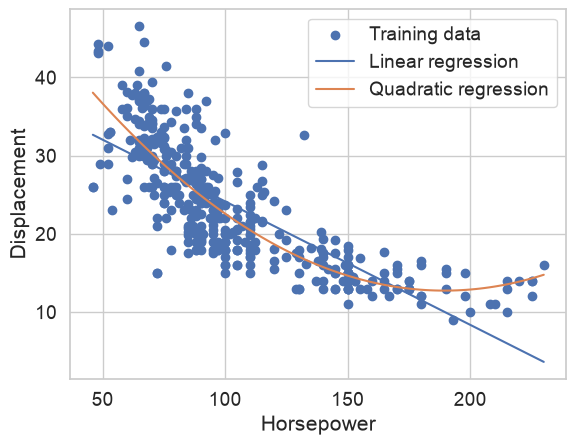

Linear RMSE: 203.2895754649215
Quadratic RMSE: 203.38381290894458


In [60]:
# Linear regression needs 2D input
x_NF_horsepower = np.asarray(x_N_horsepower).reshape(-1, 1)

lin_regr = LeastSquaresLinearRegressor()
lin_regr.fit(x_NF_horsepower, y_N_mpg)
yhat_lin_N = lin_regr.predict(x_NF_horsepower)


# Quadratic regression needs 1D input
x_N_horsepower = np.asarray(x_N_horsepower).ravel()

quad_regr = LeastSquaresQuadraticRegressor()
quad_regr.fit(x_N_horsepower, y_N_mpg)
yhat_quad_N = quad_regr.predict(x_N_horsepower)


# Grid
grid = np.linspace(
    x_N_horsepower.min(),
    x_N_horsepower.max(),
    100
)

# Linear: grid needs to be 2D
yhat_lin_grid = lin_regr.predict(grid.reshape(-1, 1))

# Quadratic: grid stays 1D
yhat_quad_grid = quad_regr.predict(grid)


# Plot
plt.scatter(
    x_N_horsepower,
    y_N_mpg,
    label="Training data"
)

plt.plot(
    grid,
    yhat_lin_grid,
    label="Linear regression"
)

plt.plot(
    grid,
    yhat_quad_grid,
    label="Quadratic regression"
)

plt.xlabel("Horsepower")
plt.ylabel("Displacement")
plt.legend()
plt.show()


# RMSE
rmse_lin = calc_root_mean_squared_error(
    y_N_displacement,
    yhat_lin_N
)

rmse_quad = calc_root_mean_squared_error(
    y_N_displacement,
    yhat_quad_N
)

print("Linear RMSE:", rmse_lin)
print("Quadratic RMSE:", rmse_quad)

| linear    | Quadratic    | linear         |   quadratic |
| ----------| -------------|----------------|----------------|
| 46.14     |   45.53     |    203.29      |      203.38     |

Linear-looking relationship and non-linear looking relationship

The relationship between displacement and horsepower looks pretty linear, if you ask me, so you might have been surprised to discover that the quadratic model achieved better rMSE on training data. Why is that the case? In particular, do you expect the quadratic model to always get better rMSE than the linear model on training data? Justify your answer.



I think because visually quadratic can have more variations than linear graph, most of the time it will perform better than linear graphs unless the graph is perfectly linear. This is because quadratic regression can have two feature vectors that it can adjust to be more closely aligned with the parameters.